# 03 - Benchmark models

Five benchmark forecasts (mean, naive, daily seasonal naive, weekly seasonal naive, drift) evaluated over the final 14 days at a **24-hour forecast horizon**, using the reusable functions in `appliance_energy.models.benchmarks`, `appliance_energy.backtest`, and `appliance_energy.evaluation`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from appliance_energy import backtest, config, data, evaluation, plotting
from appliance_energy.models import benchmarks

config.ensure_dirs()
hourly = data.load_hourly_data()
y = hourly[config.TARGET].asfreq("h")

train, test = data.train_test_split_series(y, test_steps=config.TEST_STEPS)

print("Train:", train.index.min(), "to", train.index.max(), f"({len(train)} rows)")
print("Test: ", test.index.min(), "to", test.index.max(), f"({len(test)} rows)")

Train: 2016-01-11 17:00:00 to 2016-05-13 18:00:00 (2954 rows)
Test:  2016-05-13 19:00:00 to 2016-05-27 18:00:00 (336 rows)


## Forecasting problem

| Element | Choice |
|---|---|
| Target | `Appliances`, hourly mean (Wh) |
| Forecast horizon | 24 hours |
| Test period | final 14 days (336 hours) |
| Training data | everything before the test period |
| Metrics | MAE, RMSE, MASE, Bias |

**Horizon vs. test period.** The task is a 24-hour forecast, but the test period spans 14 days. Forecasting all 336 steps in one go would measure 336-step-ahead accuracy, which is a different and much harder problem. We therefore use rolling-origin evaluation: forecast 24 hours, reveal the realised values, advance the origin, repeat (14 blocks). Every prediction is then at most 24 steps ahead while the evaluation still covers the whole test period, and no model ever sees data from the block it is predicting.

MASE is scaled by the in-sample daily seasonal-naive error, so MASE < 1 beats that reference.

## Rolling-origin benchmark forecasts

In [2]:
forecasts = {
    "mean": backtest.rolling_origin_forecast(
        benchmarks.mean_forecast, train, test, horizon=config.HORIZON, name="mean"),
    "naive": backtest.rolling_origin_forecast(
        benchmarks.naive_forecast, train, test, horizon=config.HORIZON, name="naive"),
    "seasonal_naive_daily": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train, test, horizon=config.HORIZON,
        name="seasonal_naive_daily", seasonality=config.DAILY_PERIOD),
    "seasonal_naive_weekly": backtest.rolling_origin_forecast(
        benchmarks.seasonal_naive_forecast, train, test, horizon=config.HORIZON,
        name="seasonal_naive_weekly", seasonality=config.WEEKLY_PERIOD),
    "drift": backtest.rolling_origin_forecast(
        benchmarks.drift_forecast, train, test, horizon=config.HORIZON, name="drift"),
}

results_df = evaluation.evaluate_all(forecasts, test, train, seasonality=config.DAILY_PERIOD)
results_df.round(3)

,model,MAE,RMSE,MASE,Bias
0,seasonal_naive_weekly,43.457,81.409,0.813,-13.160
1,seasonal_naive_daily,48.309,85.565,0.904,1.751
2,mean,50.258,74.938,0.941,-3.287
3,naive,85.551,110.390,1.601,50.977
4,drift,85.802,110.679,1.606,51.368


In [3]:
strongest = results_df.iloc[0]
print(f"Strongest benchmark: {strongest['model']} (MASE={strongest['MASE']:.3f})")

Strongest benchmark: seasonal_naive_weekly (MASE=0.813)


## Why the horizon matters

For comparison, the same benchmarks evaluated as a single 336-step forecast. The ranking changes materially, which is why the horizon has to match the stated task.

In [4]:
single_shot = {
    "mean": benchmarks.mean_forecast(train, len(test), test.index),
    "naive": benchmarks.naive_forecast(train, len(test), test.index),
    "seasonal_naive_daily": benchmarks.seasonal_naive_forecast(
        train, len(test), test.index, seasonality=config.DAILY_PERIOD),
    "seasonal_naive_weekly": benchmarks.seasonal_naive_forecast(
        train, len(test), test.index, seasonality=config.WEEKLY_PERIOD),
    "drift": benchmarks.drift_forecast(train, len(test), test.index),
}

single_results = evaluation.evaluate_all(single_shot, test, train, seasonality=config.DAILY_PERIOD)

comparison = (
    results_df.set_index("model")[["MASE"]].rename(columns={"MASE": "MASE_rolling_24h"})
    .join(single_results.set_index("model")[["MASE"]].rename(columns={"MASE": "MASE_single_336step"}))
)
comparison.round(3)

,MASE_rolling_24h,MASE_single_336step
model,,
seasonal_naive_weekly,0.813,0.798
seasonal_naive_daily,0.904,1.628
mean,0.941,0.942
naive,1.601,4.692
drift,1.606,4.986


`naive` and `drift` are heavily penalised over 336 steps because they extrapolate a single value or slope across two weeks. At a 24-hour horizon they are re-anchored every block and become competitive, though both still trail the seasonal benchmarks.

## Forecast plot

Saved figure to D:\UK ass\outputs\figures\03_benchmark_forecasts.png


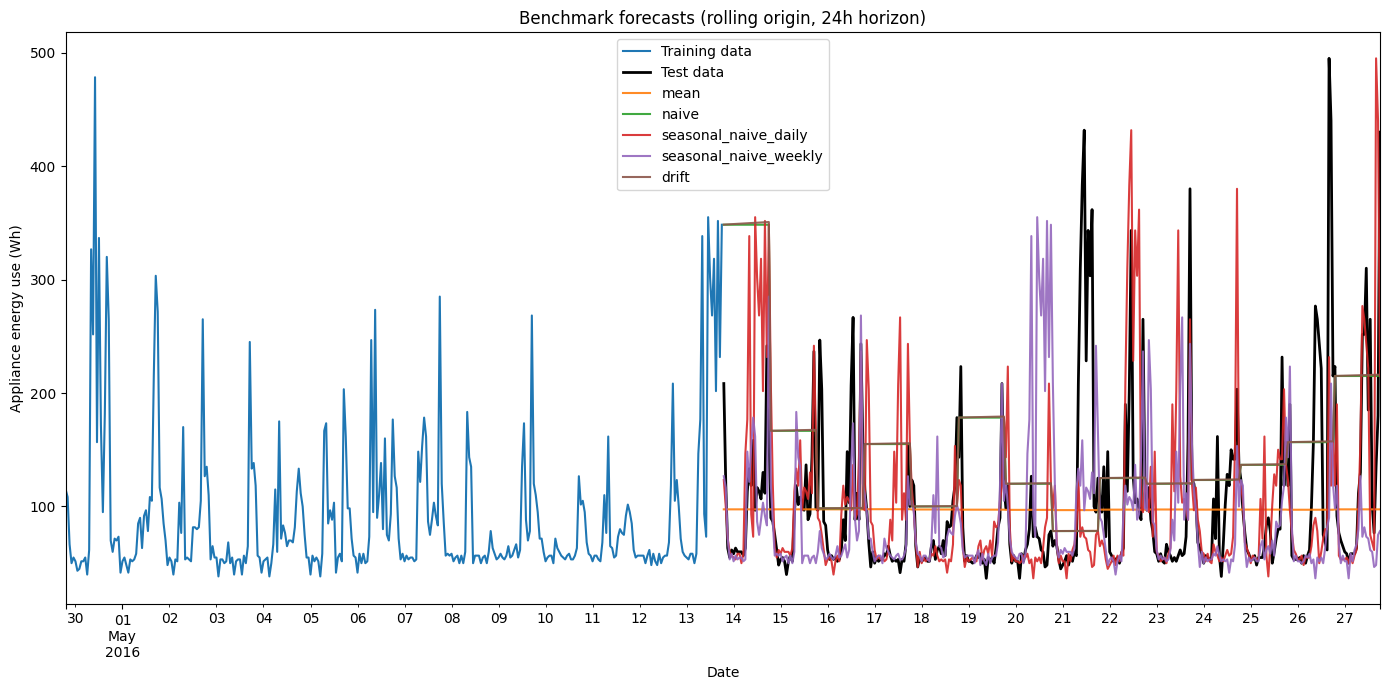

In [5]:
forecast_df = pd.DataFrame({"actual": test})
for name, pred in forecasts.items():
    forecast_df[name] = pred.reindex(test.index)

fig = plotting.plot_forecasts(train, test, forecast_df,
                              title="Benchmark forecasts (rolling origin, 24h horizon)")
plotting.save_fig(fig, config.FIGURE_DIR / "03_benchmark_forecasts.png")
plt.show()

## Interpretation

The **weekly seasonal naive** is the strongest benchmark, with the **daily seasonal naive** close behind. Both beat `mean`, `naive`, and `drift`, which tells us appliance energy use is driven mainly by repeating daily and weekly routines rather than by level or trend. Any more complex model must beat the weekly seasonal naive to justify its additional complexity.

In [6]:
forecast_df.to_csv(config.FORECAST_DIR / "benchmark_forecasts.csv")
results_df.to_csv(config.METRICS_DIR / "benchmark_comparison.csv", index=False)
print("Saved benchmark forecasts and metrics.")

Saved benchmark forecasts and metrics.
